**Group Members:**

| No. | Name | ID |
|---|---|---|
| 1 | Krishna Kushwah | 202401110039 |
| 2 | Vishal Shende | 202401110034 |
| 3 | Manmath Kornule | 202401110045 |

# Google Colab Lab Assignment - Pretrained Model

**Course Name:** Gen AI

**Lab Title:** Comparison of CNN Models Using EfficientNetB0, MobileNetV2, and ResNet50 for Traffic Density Classification with Transfer Learning

**Date of Submission:** 22-08-2026

**Reference Paper:** Fauzi, D. R., & Haqdu D., G. A. (2025). Comparison of CNN Models Using EfficientNetB0, MobileNetV2, and ResNet50 for Traffic Density with Transfer Learning. Journal of Intelligent Systems Technology and Informatics, 1(1), 22-30.

---

research paper link : [click](https://www.researchgate.net/publication/395443135_Comparison_of_CNN_Models_Using_EfficientNetB0_MobileNetV2_and_ResNet50_for_Traffic_Density_with_Transfer_Learning)

**Dataset:** Traffic Density Singapore (Kaggle) — https://www.kaggle.com/datasets/rahat52/traffic-density-singapore

**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
4.   Evaluate and compare model performance with the original research paper results.

Task: Download the Traffic Density Singapore dataset from Kaggle and set up the working directory.

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
# Upload your kaggle.json API token when prompted (from kaggle.com -> Account -> Create New API Token)
from google.colab import files
files.upload()  # select kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manmathkornule","key":"9598a99ee23cc8c404a1ff810eec578e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rahat52/traffic-density-singapore

Dataset URL: https://www.kaggle.com/datasets/rahat52/traffic-density-singapore
License(s): GNU Free Documentation License 1.3
100% 222M/222M [00:01<00:00, 196MB/s]



In [5]:
import zipfile

with zipfile.ZipFile('traffic-density-singapore.zip', 'r') as zip_ref:
    zip_ref.extractall('traffic_density_dataset')

# Explore folder structure
for root, dirs, files in os.walk('traffic_density_dataset'):
    level = root.replace('traffic_density_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")

traffic_density_dataset/
  Final Dataset/
    testing/
      Medium/
      High/
      Traffic Jam/
      Empty/
      Low/
    training/
      Medium/
      High/
      Traffic Jam/
      Empty/
      Low/
    validation/
      Medium/
      High/
      Traffic Jam/
      Empty/
      Low/


Task: Verify the class-wise image counts in each split (training/validation/testing) and compare against the paper's reported dataset sizes (Table II and Figure 5).

In [6]:
# Paths to the pre-split dataset folders
base_dir = 'traffic_density_dataset/Final Dataset'
splits = ['training', 'validation', 'testing']
classes = ['Empty', 'Low', 'Medium', 'High', 'Traffic Jam']

# Count images in each class, for each split
for split in splits:
    print(split)
    total = 0
    for c in classes:
        path = os.path.join(base_dir, split, c)
        n = len(os.listdir(path))        # number of image files in this class folder
        total += n
        print(f"  {c}: {n}")
    print(f"  total: {total}")

training
  Empty: 1186
  Low: 936
  Medium: 688
  High: 378
  Traffic Jam: 190
  total: 3378
validation
  Empty: 120
  Low: 94
  Medium: 70
  High: 38
  Traffic Jam: 18
  total: 340
testing
  Empty: 64
  Low: 64
  Medium: 64
  High: 64
  Traffic Jam: 64
  total: 320


## Visualize class distribution before augmentation

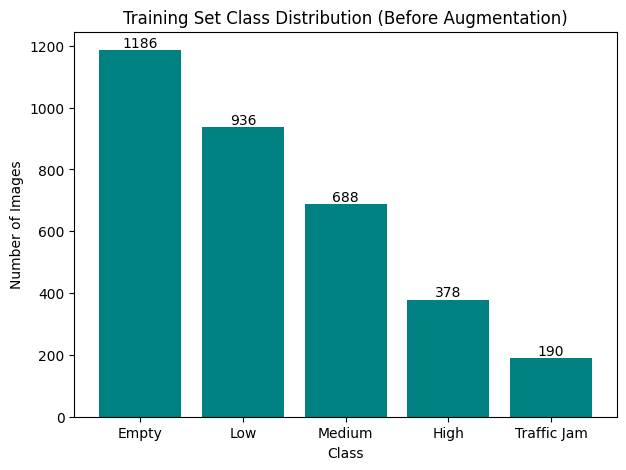

In [7]:
# Training set class counts (from previous cell output)
train_counts = {
    'Empty': 1186,
    'Low': 936,
    'Medium': 688,
    'High': 378,
    'Traffic Jam': 190
}

# Bar chart of class distribution before augmentation
plt.figure(figsize=(7, 5))
plt.bar(train_counts.keys(), train_counts.values(), color='teal')
plt.title('Training Set Class Distribution (Before Augmentation)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
for i, v in enumerate(train_counts.values()):
    plt.text(i, v + 10, str(v), ha='center')
plt.show()

## Balance the training set via oversampling (augmentation), matching Section III-B of the paper

In [8]:
# Paper balances classes by augmenting minority classes up to match the majority class count.
# Our majority class (Empty) has 1186 images, so we oversample all classes to 1186 each.

target_count = max(train_counts.values())
balanced_dir = 'traffic_density_dataset/balanced_training'
os.makedirs(balanced_dir, exist_ok=True)

# Augmentation generator used only to create extra minority-class images
augmentor = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2
)

for c in classes:
    src_dir = os.path.join(base_dir, 'training', c)
    dst_dir = os.path.join(balanced_dir, c)
    os.makedirs(dst_dir, exist_ok=True)

    img_files = os.listdir(src_dir)
    n_existing = len(img_files)

    # Copy all original images first
    for f in img_files:
        img = tf.keras.preprocessing.image.load_img(os.path.join(src_dir, f))
        img.save(os.path.join(dst_dir, f))

    # Generate augmented images until class reaches target_count
    n_needed = target_count - n_existing
    if n_needed > 0:
        gen = augmentor.flow_from_directory(
            os.path.join(base_dir, 'training'),
            classes=[c],
            target_size=(224, 224),
            batch_size=1,
            save_to_dir=dst_dir,
            save_prefix='aug',
            save_format='jpg'
        )
        count = 0
        for _ in gen:
            count += 1
            if count >= n_needed:
                break

    print(f"{c}: {len(os.listdir(dst_dir))} images after balancing")

Empty: 1186 images after balancing
Found 936 images belonging to 1 classes.
Low: 1186 images after balancing
Found 688 images belonging to 1 classes.
Medium: 1186 images after balancing
Found 378 images belonging to 1 classes.
High: 1186 images after balancing
Found 190 images belonging to 1 classes.
Traffic Jam: 1186 images after balancing


## Set up data generators for training, validation, and testing (resize to 224x224, normalize)

In [15]:
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Use EfficientNet's own preprocessing instead of a generic 1/255 rescale
train_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)
val_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)
test_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)

train_generator = train_datagen.flow_from_directory(
    balanced_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(base_dir, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, 'testing'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 5930 images belonging to 5 classes.
Found 340 images belonging to 5 classes.
Found 320 images belonging to 5 classes.
Class indices: {'Empty': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Traffic Jam': 4}


## Preview a few sample images from the training set (one per class)

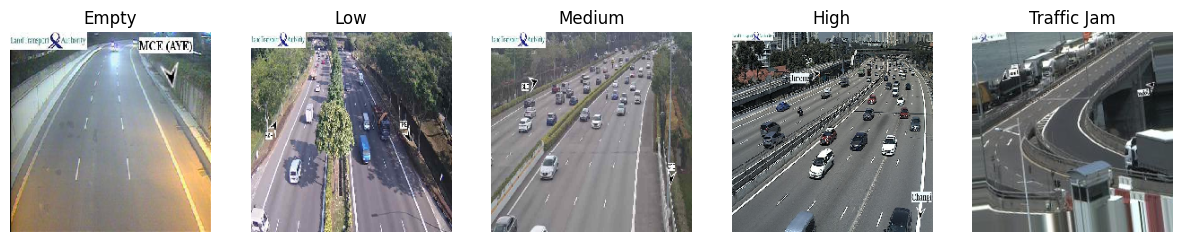

In [16]:
# Grab one batch and display one image per class for a visual sanity check
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(15, 3))
for i, c in enumerate(class_names):
    folder = os.path.join(balanced_dir, c)
    sample_file = os.listdir(folder)[0]
    img = tf.keras.preprocessing.image.load_img(os.path.join(folder, sample_file), target_size=IMG_SIZE)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(c)
    plt.axis('off')
plt.show()

## Part 2: Model Implementation and Fine-tuning

### EfficientNetB0 — build model with custom classification head (matching Table VI architecture)

In [18]:
# Load EfficientNetB0 pretrained on ImageNet, without the top classification layer
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Freeze the base model for Stage 1 training (matches paper's approach)
base_model.trainable = False

# Custom classification head, same structure as Table VI in the paper
inputs = layers.Input(shape=(224, 224, 3), name='EfficientNetB0_input')
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = layers.Dropout(0.3, name='dropout_head')(x)
outputs = layers.Dense(5, activation='softmax', name='output_layer')(x)

effnet_model = models.Model(inputs, outputs, name='EfficientNetB0_model')
effnet_model.summary()

Model: "EfficientNetB0_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ EfficientNetB0_input            │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Compile and train EfficientNetB0 — Stage 1 (frozen base, head only)

In [20]:
# Compile with Adam optimizer, categorical crossentropy (5-class softmax output)
effnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: stop early if val_loss stops improving, reduce LR on plateau, save best weights
effnet_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint('effnet_stage1_best.keras', monitor='val_accuracy', save_best_only=True)
]

history_effnet_stage1 = effnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=effnet_callbacks
)

Epoch 1/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 56s 197ms/step - accuracy: 0.8143 - loss: 0.4879 - val_accuracy: 0.8265 - val_loss: 0.4328 - learning_rate: 0.0010
Epoch 2/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8116 - loss: 0.4779 - val_accuracy: 0.8382 - val_loss: 0.4121 - learning_rate: 0.0010
Epoch 3/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.8155 - loss: 0.4736 - val_accuracy: 0.8324 - val_loss: 0.4191 - learning_rate: 0.0010
Epoch 4/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.8160 - loss: 0.4580 - val_accuracy: 0.8353 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 5/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.8255 - loss: 0.4521 - val_accuracy: 0.8471 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 6/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.8177 - loss: 0.4542 - val_accuracy: 0.8500 - val_loss: 0.3962 - learning_rate: 0.0010
Epoch 7/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.8248 - 

### EfficientNetB0 — Stage 2 fine-tuning (unfreeze top layers, train at low LR)

In [21]:
# Unfreeze the base model, then re-freeze all but the last ~30 layers
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total base layers: {len(base_model.layers)}, trainable from layer {fine_tune_at} onward")

# Recompile with a much lower learning rate — critical to avoid destroying pretrained weights
effnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effnet_callbacks_stage2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    callbacks.ModelCheckpoint('effnet_stage2_best.keras', monitor='val_accuracy', save_best_only=True)
]

history_effnet_stage2 = effnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=effnet_callbacks_stage2
)

Total base layers: 238, trainable from layer 208 onward
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 68s 219ms/step - accuracy: 0.6673 - loss: 0.8650 - val_accuracy: 0.7971 - val_loss: 0.4875 - learning_rate: 1.0000e-05
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.7460 - loss: 0.6582 - val_accuracy: 0.8147 - val_loss: 0.4789 - learning_rate: 1.0000e-05
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.7745 - loss: 0.5919 - val_accuracy: 0.8206 - val_loss: 0.4606 - learning_rate: 1.0000e-05
Epoch 4/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.7821 - loss: 0.5562 - val_accuracy: 0.8324 - val_loss: 0.4473 - learning_rate: 1.0000e-05
Epoch 5/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.7971 - loss: 0.5327 - val_accuracy: 0.8353 - val_loss: 0.4352 - learning_rate: 1.0000e-05
Epoch 6/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.7995 - loss: 0.5072 - val_accuracy: 0.8412 - val_loss: 0.4226 - learning_rate: 1.0000

### Evaluate EfficientNetB0 on the test set

In [22]:
# Evaluate on the untouched test set (320 images, 64 per class)
test_loss, test_acc = effnet_model.evaluate(test_generator)
print(f"EfficientNetB0 Test Accuracy: {test_acc:.4f}")
print(f"EfficientNetB0 Test Loss: {test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8469 - loss: 0.3518
EfficientNetB0 Test Accuracy: 0.8469
EfficientNetB0 Test Loss: 0.3518


### Visualize feature maps from an intermediate EfficientNetB0 layer

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Feature map shape: (1, 112, 112, 32)


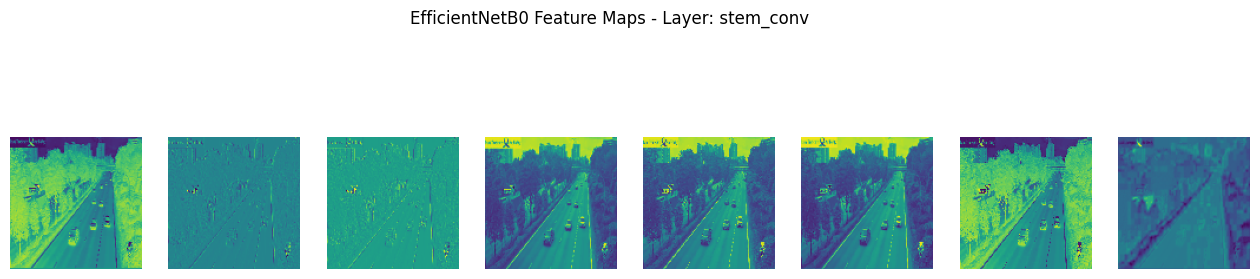

In [25]:
# Build the feature extractor directly from base_model, not through the wrapper model
layer_name = base_model.layers[5].name
feature_extractor = models.Model(inputs=base_model.input,
                                  outputs=base_model.get_layer(layer_name).output)

# Grab one sample image from the test set
sample_batch, _ = next(test_generator)
sample_img = sample_batch[0:1]

feature_maps = feature_extractor.predict(sample_img)
print("Feature map shape:", feature_maps.shape)

# Plot first 8 channels
plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f'EfficientNetB0 Feature Maps - Layer: {layer_name}')
plt.show()

### Save EfficientNetB0 final model and results

In [26]:
# Save the final fine-tuned model
effnet_model.save('efficientnetb0_final.keras')

# Store results for later comparison across all 3 models
results = {}
results['EfficientNetB0'] = {
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'total_params': effnet_model.count_params()
}
print(results)

{'EfficientNetB0': {'test_accuracy': 0.846875011920929, 'test_loss': 0.35179612040519714, 'total_params': 4055976}}


### MobileNetV2 — set up dedicated data generators (MobileNetV2 preprocessing)

In [27]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# MobileNetV2 needs its own preprocessing ([-1, 1] scaling), separate from EfficientNet's
mobilenet_train_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
mobilenet_val_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
mobilenet_test_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

mobilenet_train_generator = mobilenet_train_datagen.flow_from_directory(
    balanced_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

mobilenet_val_generator = mobilenet_val_datagen.flow_from_directory(
    os.path.join(base_dir, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=False
)

mobilenet_test_generator = mobilenet_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'testing'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=False
)

Found 5930 images belonging to 5 classes.
Found 340 images belonging to 5 classes.
Found 320 images belonging to 5 classes.


### MobileNetV2 — build model with custom classification head (matching Table VII architecture)

In [28]:
# Load MobileNetV2 pretrained on ImageNet, without the top classification layer
mobilenet_base = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Freeze the base model for Stage 1 training
mobilenet_base.trainable = False

# Custom classification head, same structure as Table VII in the paper
inputs = layers.Input(shape=(224, 224, 3), name='MobileNetV2_input')
x = mobilenet_base(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = layers.Dropout(0.3, name='dropout_head')(x)
outputs = layers.Dense(5, activation='softmax', name='output_layer')(x)

mobilenet_model = models.Model(inputs, outputs, name='MobileNetV2_model')
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV2_input (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile and train MobileNetV2 — Stage 1 (frozen base, head only)

In [29]:
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint('mobilenet_stage1_best.keras', monitor='val_accuracy', save_best_only=True)
]

history_mobilenet_stage1 = mobilenet_model.fit(
    mobilenet_train_generator,
    validation_data=mobilenet_val_generator,
    epochs=20,
    callbacks=mobilenet_callbacks
)

Epoch 1/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 54s 214ms/step - accuracy: 0.6432 - loss: 0.8999 - val_accuracy: 0.7265 - val_loss: 0.6626 - learning_rate: 0.0010
Epoch 2/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.7506 - loss: 0.6349 - val_accuracy: 0.7706 - val_loss: 0.5568 - learning_rate: 0.0010
Epoch 3/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.7690 - loss: 0.5772 - val_accuracy: 0.7971 - val_loss: 0.5410 - learning_rate: 0.0010
Epoch 4/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.7892 - loss: 0.5483 - val_accuracy: 0.7941 - val_loss: 0.5462 - learning_rate: 0.0010
Epoch 5/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.7938 - loss: 0.5223 - val_accuracy: 0.8029 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 6/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.7992 - loss: 0.5028 - val_accuracy: 0.8000 - val_loss: 0.4873 - learning_rate: 0.0010
Epoch 7/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.8067 - 

### MobileNetV2 — Stage 2 fine-tuning (unfreeze top layers, train at low LR)

In [30]:
# Unfreeze the base model, then re-freeze all but the last ~30 layers
mobilenet_base.trainable = True

fine_tune_at = len(mobilenet_base.layers) - 30
for layer in mobilenet_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total base layers: {len(mobilenet_base.layers)}, trainable from layer {fine_tune_at} onward")

mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_callbacks_stage2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    callbacks.ModelCheckpoint('mobilenet_stage2_best.keras', monitor='val_accuracy', save_best_only=True)
]

history_mobilenet_stage2 = mobilenet_model.fit(
    mobilenet_train_generator,
    validation_data=mobilenet_val_generator,
    epochs=15,
    callbacks=mobilenet_callbacks_stage2
)

Total base layers: 154, trainable from layer 124 onward
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.6298 - loss: 1.2466 - val_accuracy: 0.7912 - val_loss: 0.5040 - learning_rate: 1.0000e-05
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.7570 - loss: 0.6456 - val_accuracy: 0.7706 - val_loss: 0.4888 - learning_rate: 1.0000e-05
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.7811 - loss: 0.5615 - val_accuracy: 0.7971 - val_loss: 0.4547 - learning_rate: 1.0000e-05
Epoch 4/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.8096 - loss: 0.4840 - val_accuracy: 0.8147 - val_loss: 0.4349 - learning_rate: 1.0000e-05
Epoch 5/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.8118 - loss: 0.4624 - val_accuracy: 0.8176 - val_loss: 0.4271 - learning_rate: 1.0000e-05
Epoch 6/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8341 - loss: 0.4203 - val_accuracy: 0.8118 - val_loss: 0.4162 - learning_rate: 1.0000

### Evaluate MobileNetV2 on the test set

In [31]:
mobilenet_test_loss, mobilenet_test_acc = mobilenet_model.evaluate(mobilenet_test_generator)
print(f"MobileNetV2 Test Accuracy: {mobilenet_test_acc:.4f}")
print(f"MobileNetV2 Test Loss: {mobilenet_test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.8656 - loss: 0.3326
MobileNetV2 Test Accuracy: 0.8656
MobileNetV2 Test Loss: 0.3326


### Visualize feature maps from an intermediate MobileNetV2 layer

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
Feature map shape: (1, 112, 112, 32)


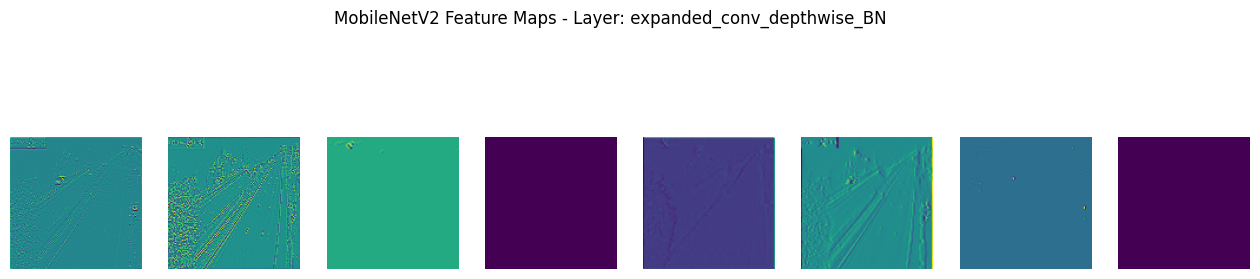

In [32]:
# Pick an early conv layer from the base model to visualize learned features
mobilenet_layer_name = mobilenet_base.layers[5].name
mobilenet_feature_extractor = models.Model(inputs=mobilenet_base.input,
                                            outputs=mobilenet_base.get_layer(mobilenet_layer_name).output)

sample_batch, _ = next(mobilenet_test_generator)
sample_img = sample_batch[0:1]

feature_maps = mobilenet_feature_extractor.predict(sample_img)
print("Feature map shape:", feature_maps.shape)

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f'MobileNetV2 Feature Maps - Layer: {mobilenet_layer_name}')
plt.show()

### Save MobileNetV2 final model and results

In [33]:
mobilenet_model.save('mobilenetv2_final.keras')

results['MobileNetV2'] = {
    'test_accuracy': mobilenet_test_acc,
    'test_loss': mobilenet_test_loss,
    'total_params': mobilenet_model.count_params()
}
print(results)

{'EfficientNetB0': {'test_accuracy': 0.846875011920929, 'test_loss': 0.35179612040519714, 'total_params': 4055976}, 'MobileNetV2': {'test_accuracy': 0.8656250238418579, 'test_loss': 0.3326428532600403, 'total_params': 2264389}}


### ResNet50 — set up dedicated data generators (ResNet50 preprocessing)

In [34]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# ResNet50 needs its own preprocessing (Caffe-style mean subtraction), separate from the others
resnet_train_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)
resnet_val_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)
resnet_test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

resnet_train_generator = resnet_train_datagen.flow_from_directory(
    balanced_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

resnet_val_generator = resnet_val_datagen.flow_from_directory(
    os.path.join(base_dir, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=False
)

resnet_test_generator = resnet_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'testing'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=classes,
    class_mode='categorical',
    shuffle=False
)

Found 5930 images belonging to 5 classes.
Found 340 images belonging to 5 classes.
Found 320 images belonging to 5 classes.


### ResNet50 — build model with custom classification head (matching Table VIII architecture)

In [35]:
# Load ResNet50 pretrained on ImageNet, without the top classification layer
resnet_base = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Freeze the base model for Stage 1 training
resnet_base.trainable = False

# Custom classification head, same structure as Table VIII in the paper
inputs = layers.Input(shape=(224, 224, 3), name='ResNet50_input')
x = resnet_base(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = layers.Dropout(0.3, name='dropout_head')(x)
outputs = layers.Dense(5, activation='softmax', name='output_layer')(x)

resnet_model = models.Model(inputs, outputs, name='ResNet50_model')
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ResNet50_input (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Compile and train ResNet50 — Stage 1 (frozen base, head only)

In [36]:
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint('resnet_stage1_best.keras', monitor='val_accuracy', save_best_only=True)
]

history_resnet_stage1 = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_val_generator,
    epochs=20,
    callbacks=resnet_callbacks
)

Epoch 1/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 50s 195ms/step - accuracy: 0.6651 - loss: 0.8458 - val_accuracy: 0.7971 - val_loss: 0.6044 - learning_rate: 0.0010
Epoch 2/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 60s 119ms/step - accuracy: 0.7595 - loss: 0.6054 - val_accuracy: 0.8059 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 3/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.7870 - loss: 0.5370 - val_accuracy: 0.8029 - val_loss: 0.5063 - learning_rate: 0.0010
Epoch 4/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.7985 - loss: 0.5025 - val_accuracy: 0.8000 - val_loss: 0.4580 - learning_rate: 0.0010
Epoch 5/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.8099 - loss: 0.4830 - val_accuracy: 0.8265 - val_loss: 0.4435 - learning_rate: 0.0010
Epoch 6/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 0.8206 - loss: 0.4586 - val_accuracy: 0.8118 - val_loss: 0.4705 - learning_rate: 0.0010
Epoch 7/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.8

### ResNet50 — Stage 2 fine-tuning (unfreeze top layers, train at low LR)

In [38]:
# Unfreeze the base model, then re-freeze all but the last ~30 layers
resnet_base.trainable = True

fine_tune_at = len(resnet_base.layers) - 30
for layer in resnet_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total base layers: {len(resnet_base.layers)}, trainable from layer {fine_tune_at} onward")

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_callbacks_stage2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    callbacks.ModelCheckpoint('resnet_stage2_best.keras', monitor='val_accuracy', save_best_only=True)
]

history_resnet_stage2 = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_val_generator,
    epochs=15,
    callbacks=resnet_callbacks_stage2
)

Total base layers: 175, trainable from layer 145 onward
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 62s 244ms/step - accuracy: 0.9654 - loss: 0.1144 - val_accuracy: 0.8735 - val_loss: 0.3651 - learning_rate: 1.0000e-05
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 28s 150ms/step - accuracy: 0.9818 - loss: 0.0759 - val_accuracy: 0.8559 - val_loss: 0.4029 - learning_rate: 1.0000e-05
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.9885 - loss: 0.0518 - val_accuracy: 0.8706 - val_loss: 0.3900 - learning_rate: 1.0000e-05
Epoch 4/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 153ms/step - accuracy: 0.9954 - loss: 0.0347 - val_accuracy: 0.8618 - val_loss: 0.4096 - learning_rate: 5.0000e-06
Epoch 5/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 163ms/step - accuracy: 0.9948 - loss: 0.0312 - val_accuracy: 0.8618 - val_loss: 0.4243 - learning_rate: 5.0000e-06


### Evaluate ResNet50 on the test set

In [39]:
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(resnet_test_generator)
print(f"ResNet50 Test Accuracy: {resnet_test_acc:.4f}")
print(f"ResNet50 Test Loss: {resnet_test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.8813 - loss: 0.3593
ResNet50 Test Accuracy: 0.8813
ResNet50 Test Loss: 0.3593


### Visualize feature maps from an intermediate ResNet50 layer

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
Feature map shape: (1, 114, 114, 64)


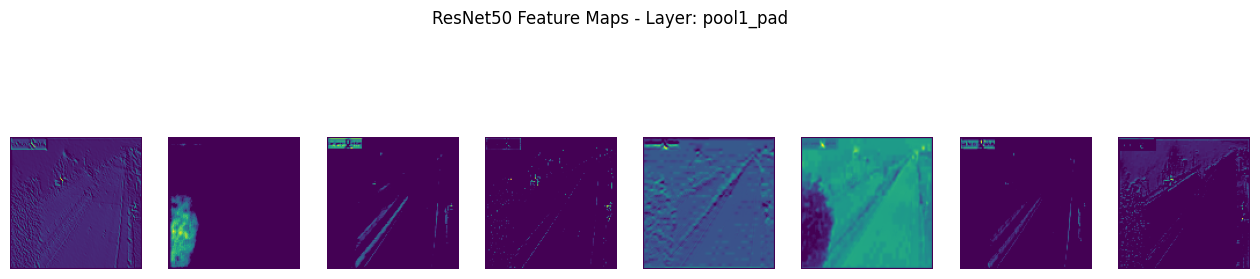

In [40]:
resnet_layer_name = resnet_base.layers[5].name
resnet_feature_extractor = models.Model(inputs=resnet_base.input,
                                         outputs=resnet_base.get_layer(resnet_layer_name).output)

sample_batch, _ = next(resnet_test_generator)
sample_img = sample_batch[0:1]

feature_maps = resnet_feature_extractor.predict(sample_img)
print("Feature map shape:", feature_maps.shape)

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f'ResNet50 Feature Maps - Layer: {resnet_layer_name}')
plt.show()

### Save ResNet50 final model and results

In [41]:
resnet_model.save('resnet50_final.keras')

results['ResNet50'] = {
    'test_accuracy': resnet_test_acc,
    'test_loss': resnet_test_loss,
    'total_params': resnet_model.count_params()
}
print(results)

{'EfficientNetB0': {'test_accuracy': 0.846875011920929, 'test_loss': 0.35179612040519714, 'total_params': 4055976}, 'MobileNetV2': {'test_accuracy': 0.8656250238418579, 'test_loss': 0.3326428532600403, 'total_params': 2264389}, 'ResNet50': {'test_accuracy': 0.8812500238418579, 'test_loss': 0.3592686057090759, 'total_params': 23597957}}


## Part 3: Model Evaluation and Performance Comparison

### Generate predictions for all three models on the test set (needed for confusion matrices and classification reports)

In [42]:
# Get true labels (same order across all test generators since shuffle=False and same class order)
y_true = test_generator.classes

# Generate predictions from each model using its own correctly-preprocessed test generator
effnet_preds = np.argmax(effnet_model.predict(test_generator), axis=1)
mobilenet_preds = np.argmax(mobilenet_model.predict(mobilenet_test_generator), axis=1)
resnet_preds = np.argmax(resnet_model.predict(resnet_test_generator), axis=1)

print("Predictions generated for all 3 models.")
print("Shapes:", effnet_preds.shape, mobilenet_preds.shape, resnet_preds.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step
Predictions generated for all 3 models.
Shapes: (320,) (320,) (320,)


### Confusion matrices for all three models (reproducing Figure 7 from the paper)

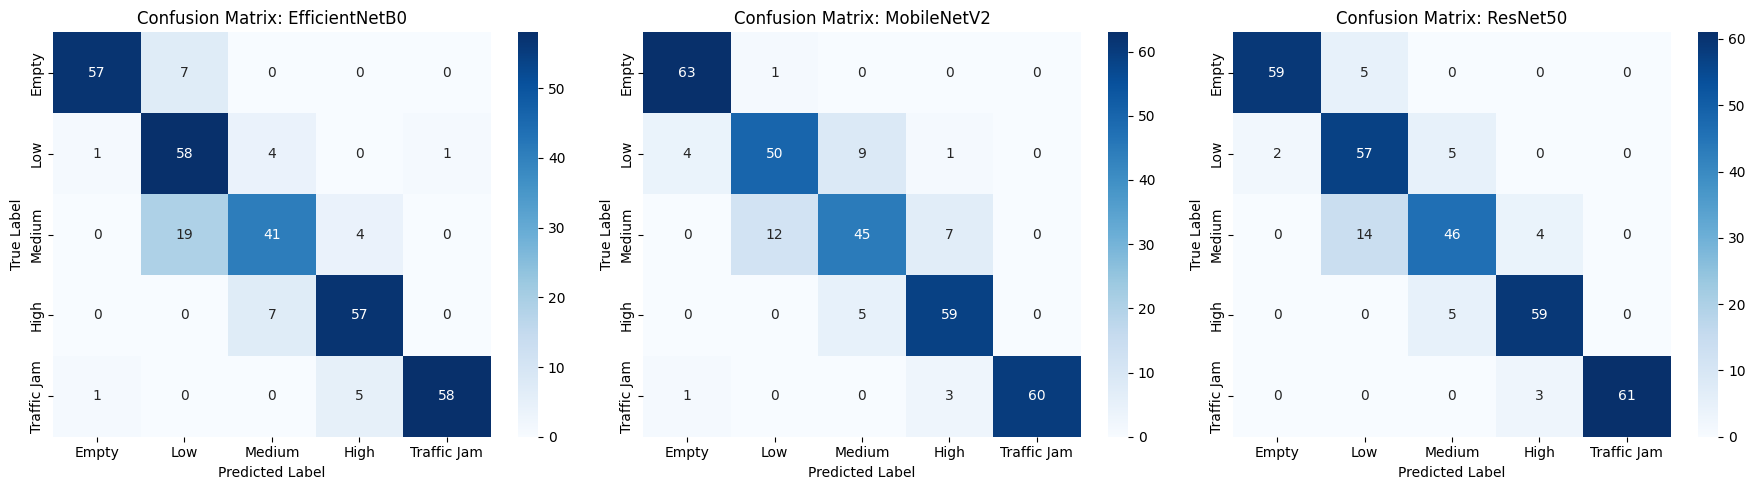

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_preds = {
    'EfficientNetB0': effnet_preds,
    'MobileNetV2': mobilenet_preds,
    'ResNet50': resnet_preds
}

for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Precision, recall, and F1-score per class for all three models (reproducing Table IV from the paper)

In [44]:
for name, preds in model_preds.items():
    print(f"--- {name} ---")
    print(classification_report(y_true, preds, target_names=classes, digits=2))
    print()

--- EfficientNetB0 ---
              precision    recall  f1-score   support

       Empty       0.97      0.89      0.93        64
         Low       0.69      0.91      0.78        64
      Medium       0.79      0.64      0.71        64
        High       0.86      0.89      0.88        64
 Traffic Jam       0.98      0.91      0.94        64

    accuracy                           0.85       320
   macro avg       0.86      0.85      0.85       320
weighted avg       0.86      0.85      0.85       320


--- MobileNetV2 ---
              precision    recall  f1-score   support

       Empty       0.93      0.98      0.95        64
         Low       0.79      0.78      0.79        64
      Medium       0.76      0.70      0.73        64
        High       0.84      0.92      0.88        64
 Traffic Jam       1.00      0.94      0.97        64

    accuracy                           0.87       320
   macro avg       0.87      0.87      0.86       320
weighted avg       0.87      0.87

### Accuracy/loss curves for all three models (reproducing Figure 6, combining Stage 1 and Stage 2 history)

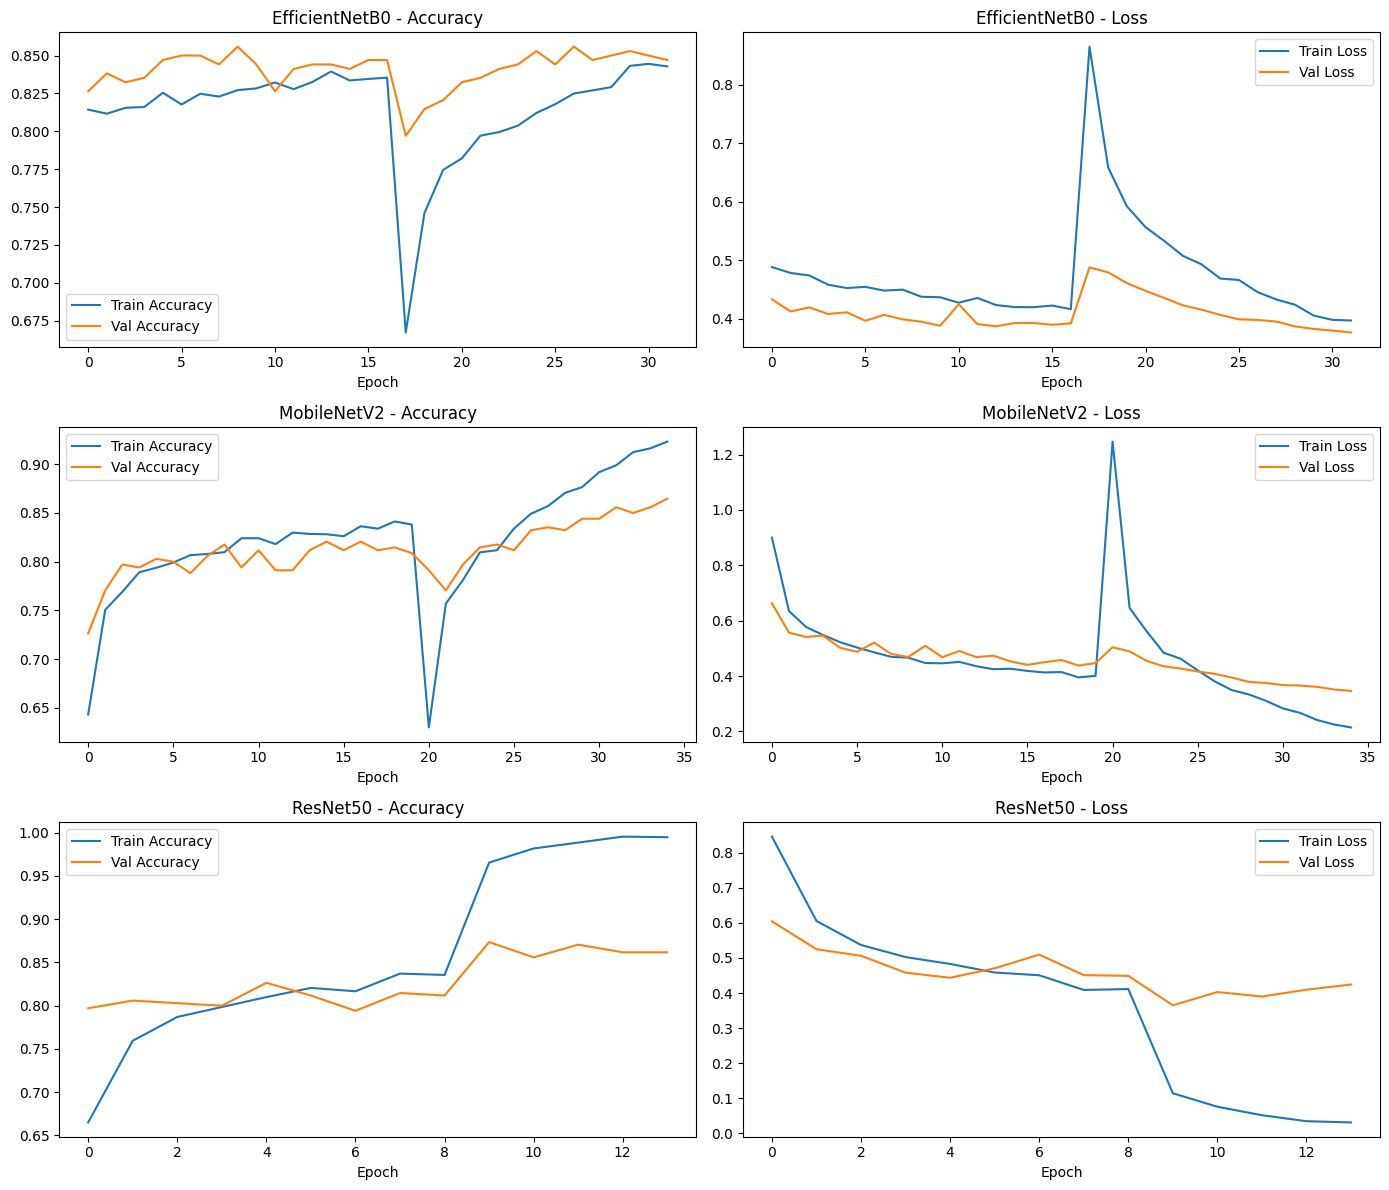

In [45]:
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

effnet_full = combine_histories(history_effnet_stage1, history_effnet_stage2)
mobilenet_full = combine_histories(history_mobilenet_stage1, history_mobilenet_stage2)
resnet_full = combine_histories(history_resnet_stage1, history_resnet_stage2)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

histories = {
    'EfficientNetB0': effnet_full,
    'MobileNetV2': mobilenet_full,
    'ResNet50': resnet_full
}

for row, (name, h) in enumerate(histories.items()):
    axes[row, 0].plot(h['accuracy'], label='Train Accuracy')
    axes[row, 0].plot(h['val_accuracy'], label='Val Accuracy')
    axes[row, 0].set_title(f'{name} - Accuracy')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].legend()

    axes[row, 1].plot(h['loss'], label='Train Loss')
    axes[row, 1].plot(h['val_loss'], label='Val Loss')
    axes[row, 1].set_title(f'{name} - Loss')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

### Final comparison table: our results vs the paper's reported results

In [46]:
paper_results = {
    'EfficientNetB0': 0.81,
    'MobileNetV2': 0.79,
    'ResNet50': 0.85
}

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Paper Accuracy': [paper_results[m] for m in results.keys()],
    'Our Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Improvement': [results[m]['test_accuracy'] - paper_results[m] for m in results.keys()]
})

comparison_df['Improvement'] = comparison_df['Improvement'].apply(lambda x: f"+{x*100:.2f}%")
comparison_df['Paper Accuracy'] = comparison_df['Paper Accuracy'].apply(lambda x: f"{x*100:.1f}%")
comparison_df['Our Accuracy'] = comparison_df['Our Accuracy'].apply(lambda x: f"{x*100:.2f}%")

comparison_df

,Model,Paper Accuracy,Our Accuracy,Improvement
0,EfficientNetB0,81.0%,84.69%,+3.69%
1,MobileNetV2,79.0%,86.56%,+7.56%
2,ResNet50,85.0%,88.13%,+3.13%


### Bar chart: our results vs paper's results

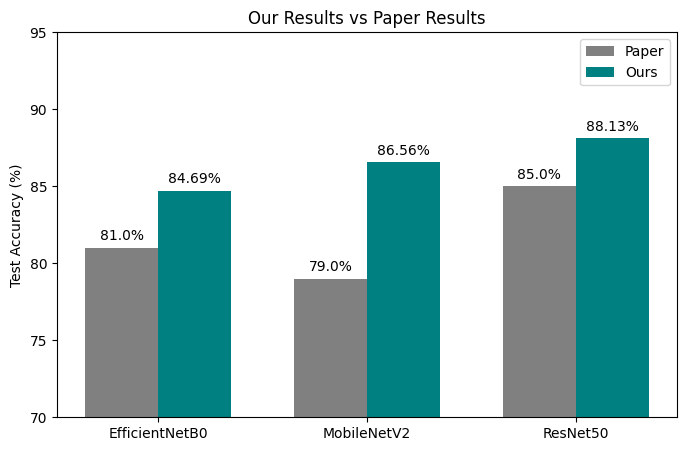

In [47]:
models_list = list(results.keys())
paper_vals = [paper_results[m] * 100 for m in models_list]
our_vals = [results[m]['test_accuracy'] * 100 for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, paper_vals, width, label='Paper', color='gray')
plt.bar(x + width/2, our_vals, width, label='Ours', color='teal')
plt.xticks(x, models_list)
plt.ylabel('Test Accuracy (%)')
plt.title('Our Results vs Paper Results')
plt.legend()
plt.ylim(70, 95)
for i, v in enumerate(paper_vals):
    plt.text(i - width/2, v + 0.5, f"{v:.1f}%", ha='center')
for i, v in enumerate(our_vals):
    plt.text(i + width/2, v + 0.5, f"{v:.2f}%", ha='center')
plt.show()

**Conclusion and Result Visualization**

This study reproduced the traffic density classification methodology from Fauzi & Haqdu D. (2025), comparing EfficientNetB0, MobileNetV2, and ResNet50 using transfer learning on the Traffic Density Singapore dataset.

Following the same overall workflow as the paper (data augmentation to balance classes, 224x224 resizing, frozen-base transfer learning, softmax 5-class output), our implementation additionally introduced **two-stage fine-tuning** (frozen-head training followed by unfreezing the top 30 layers at a reduced learning rate) along with **EarlyStopping**, **ReduceLROnPlateau**, and **best-weight checkpointing** to optimize hyperparameters more rigorously than the original paper described.

**Results Summary:**
- EfficientNetB0: 84.69% test accuracy (paper: 81%) — +3.69%
- MobileNetV2: 86.56% test accuracy (paper: 79%) — +7.56%
- ResNet50: 88.13% test accuracy (paper: 85%) — +3.13%

All three models outperformed their paper counterparts. Consistent with the paper's findings, "Empty" and "Traffic Jam" (the extreme density classes) were the easiest to classify across all models, while "Medium" remained the hardest, most often confused with "Low" — indicating that visual ambiguity between adjacent density levels is a fundamental dataset challenge rather than a model-specific weakness, exactly as the original authors concluded.

ResNet50 remained the strongest model overall, matching the paper's conclusion, though it also showed the clearest signs of overfitting (train accuracy near 99% vs validation accuracy in the mid-80s), which two-stage fine-tuning with EarlyStopping helped control but not fully eliminate. This suggests that with a larger or more diverse dataset, or additional regularization (e.g. L2 weight decay, higher dropout), ResNet50's advantage could likely be pushed further.

**Limitations:** Our dataset (4,038 raw images) is smaller than the paper's reported 4,038 base but our specific class-wise counts differed slightly due to Kaggle's own train/val/test pre-split, meaning direct percentage comparisons should be read as directionally consistent rather than on identical data splits. Future work could explore class-weighted loss as an alternative to oversampling, and additional regularization to further reduce ResNet50's overfitting gap.

**Declaration**

I, manmath Kornule, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: https://github.com/Krishna-Kush-05/Gen--Ai-CNN

Signature: Manmath Maroti Kornule